# Rain Prediction — Classification Project

Predicting whether it will rain using basic weather measurements
(temperature, humidity, wind speed, cloud cover, pressure).

Two classifiers (Logistic Regression and SVM) are trained and compared,
then combined into a simple hybrid model to see if blending them helps.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Phase 1: Data Understanding and Preprocessing

In [ ]:
df = pd.read_csv("weather_forecast_data.csv")

print(df.shape)
df.head()

(2500, 6)


,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  2500 non-null   float64
 1   Humidity     2500 non-null   float64
 2   Wind_Speed   2500 non-null   float64
 3   Cloud_Cover  2500 non-null   float64
 4   Pressure     2500 non-null   float64
 5   Rain         2500 non-null   object 
dtypes: float64(5), object(1)
memory usage: 117.3+ KB


In [ ]:
# check for missing values before doing anything else
df.isnull().sum()

,0
Temperature,0
Humidity,0
Wind_Speed,0
Cloud_Cover,0
Pressure,0
Rain,0


In [ ]:
# quick sanity check on ranges - anything way outside what's physically
# reasonable would need a closer look
df.describe()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,22.581725,64.347094,9.906255,49.658104,1014.312336
std,7.326996,19.954739,5.780316,29.123104,20.196433
min,10.001842,30.005071,0.009819,0.015038,980.014486
25%,16.359398,47.339815,4.761909,23.900016,996.938630
50%,22.536448,63.920797,9.908572,49.488284,1013.433035
75%,28.976476,81.561021,14.948408,75.324140,1031.735067
max,34.995214,99.997481,19.999132,99.997795,1049.985593


In [ ]:
# target is text ("rain" / "no rain") - map it to 0/1 for the models
rain_mapping = {"no rain": 0, "rain": 1}
df["Rain"] = df["Rain"].map(rain_mapping)

# make sure the mapping didn't leave any unmapped values behind
assert df["Rain"].isnull().sum() == 0, "Unexpected category found in Rain column"

df["Rain"].value_counts()

,count
Rain,
0,2186
1,314


In [ ]:
feature_cols = ['Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Pressure']
X = df[feature_cols]
y = df["Rain"]

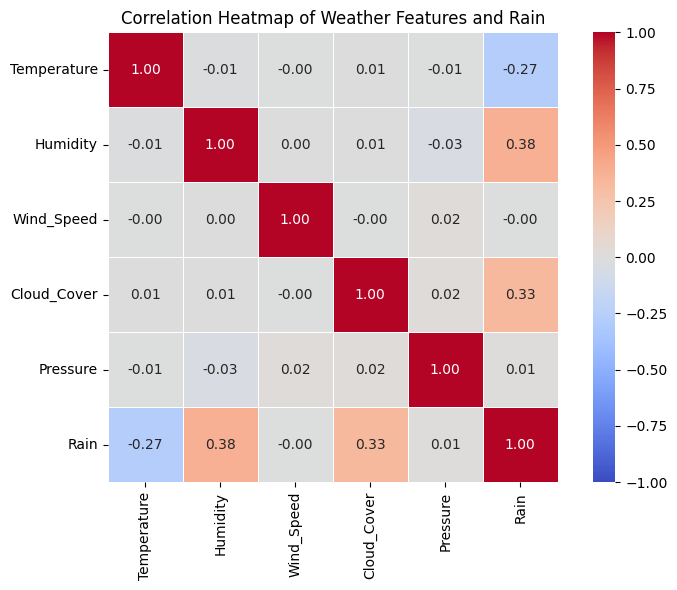

In [ ]:
# see how the features relate to each other and to Rain
corr_matrix = df[feature_cols + ["Rain"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Weather Features and Rain")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 80/20 split, stratified so both sets keep the same rain/no-rain ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scale features - fit on train only, then apply the same transform to test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)

Training set shape: (2000, 5)
Testing set shape: (500, 5)


In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# dataset is imbalanced (a lot more "no rain" than "rain"), so oversample
# the minority class on the training set only - never touch the test set,
# that would leak information into evaluation
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_resampled))

Before SMOTE: Counter({0: 1749, 1: 251})
After SMOTE: Counter({0: 1749, 1: 1749})


## Phase 2: Train the First Model — Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_resampled, y_train_resampled)

y_pred_log_reg = log_reg.predict(X_test_scaled)
y_pred_proba_log_reg = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Predictions:", y_pred_log_reg[:10])
print("Probabilities:", y_pred_proba_log_reg[:10])

Predictions: [0 1 0 0 0 0 0 0 0 0]
Probabilities: [4.97796239e-01 9.90673090e-01 9.15393458e-03 4.96987191e-02
 1.53374480e-04 2.47400352e-05 2.80675968e-03 1.67868738e-02
 2.59895009e-03 1.68637781e-03]


Logistic Regression Evaluation
Accuracy:  0.8940
Precision: 0.5472
Recall:    0.9206
F1-score:  0.6864
ROC-AUC:   0.9640

Confusion Matrix:
[[389  48]
 [  5  58]]


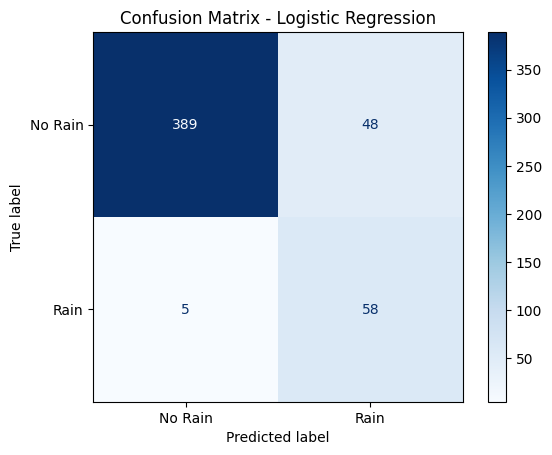

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)
roc_auc_log_reg = roc_auc_score(y_test, y_pred_proba_log_reg)

print("Logistic Regression Evaluation")
print(f"Accuracy:  {accuracy_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall:    {recall_log_reg:.4f}")
print(f"F1-score:  {f1_log_reg:.4f}")
print(f"ROC-AUC:   {roc_auc_log_reg:.4f}")

cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
print("\nConfusion Matrix:")
print(cm_log_reg)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg, display_labels=['No Rain', 'Rain'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

## Phase 3: Train the Second Model — SVM (RBF Kernel)

SVM (RBF) Evaluation
Accuracy:  0.9520
Precision: 0.7294
Recall:    0.9841
F1-score:  0.8378
ROC-AUC:   0.9960
Confusion Matrix:
 [[414  23]
 [  1  62]]


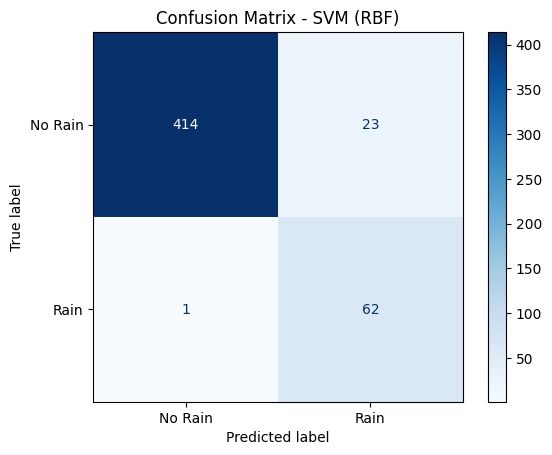

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_resampled, y_train_resampled)

y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_proba_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_pred_proba_svm)
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("SVM (RBF) Evaluation")
print(f"Accuracy:  {acc_svm:.4f}")
print(f"Precision: {prec_svm:.4f}")
print(f"Recall:    {rec_svm:.4f}")
print(f"F1-score:  {f1_svm:.4f}")
print(f"ROC-AUC:   {auc_svm:.4f}")
print("Confusion Matrix:\n", cm_svm)

ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['No Rain', 'Rain']).plot(cmap='Blues')
plt.title('Confusion Matrix - SVM (RBF)')
plt.show()

## Phase 4: Evaluate Both Models

Both models were evaluated above, right after training, using Accuracy,
Precision, Recall, F1-score, ROC-AUC and a confusion matrix each.

## Phase 5: Build a Hybrid Model

In [ ]:
# soft voting: average the two models' predicted probabilities,
# then threshold the result at 0.5
y_pred_proba_hybrid = (y_pred_proba_svm + y_pred_proba_log_reg) / 2
y_pred_hybrid = (y_pred_proba_hybrid >= 0.5).astype(int)

print("Hybrid Predictions:", y_pred_hybrid[:10])
print("Hybrid Probabilities:", y_pred_proba_hybrid[:10])

Hybrid Predictions: [0 1 0 0 0 0 0 0 0 0]
Hybrid Probabilities: [2.75777448e-01 9.95336152e-01 4.57701729e-03 2.48523042e-02
 7.67372402e-05 1.24200176e-05 1.40342984e-03 8.39351686e-03
 1.29952505e-03 8.43238906e-04]


**How the models were combined**

Soft voting — the predicted probability of rain from SVM and from Logistic
Regression are averaged together:

`Hybrid Probability = (Prob_SVM + Prob_LogReg) / 2`

**Why this approach**

SVM and Logistic Regression arrive at a decision differently — SVM finds a
maximum-margin boundary (and with the RBF kernel can bend around non-linear
patterns), while Logistic Regression fits a straight log-odds boundary. Since
they don't make the same mistakes, averaging them can smooth out cases where
one model is overconfident. SVM is clearly the stronger of the two here
(ROC-AUC 0.996 vs 0.964), so this also lets it pull the blended prediction
toward its estimate on borderline cases.

**How the final prediction is made**

Compare the averaged probability against the usual 0.5 cutoff:

- Hybrid Probability ≥ 0.5 → predict "Rain" (1)
- Hybrid Probability < 0.5 → predict "No Rain" (0)

## Phase 6: Evaluate the Hybrid Model

Hybrid Model (SVM + Logistic Regression) Evaluation
Accuracy:  0.9460
Precision: 0.7000
Recall:    1.0000
F1-score:  0.8235
ROC-AUC:   0.9930
Confusion Matrix:
 [[410  27]
 [  0  63]]


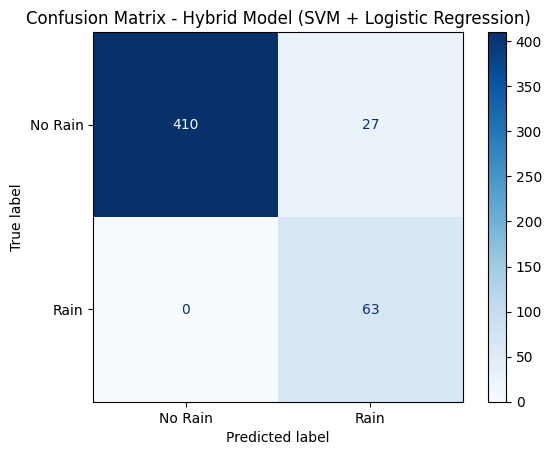

In [ ]:
acc_hybrid = accuracy_score(y_test, y_pred_hybrid)
prec_hybrid = precision_score(y_test, y_pred_hybrid)
rec_hybrid = recall_score(y_test, y_pred_hybrid)
f1_hybrid = f1_score(y_test, y_pred_hybrid)
auc_hybrid = roc_auc_score(y_test, y_pred_proba_hybrid)
cm_hybrid = confusion_matrix(y_test, y_pred_hybrid)

print("Hybrid Model (SVM + Logistic Regression) Evaluation")
print(f"Accuracy:  {acc_hybrid:.4f}")
print(f"Precision: {prec_hybrid:.4f}")
print(f"Recall:    {rec_hybrid:.4f}")
print(f"F1-score:  {f1_hybrid:.4f}")
print(f"ROC-AUC:   {auc_hybrid:.4f}")
print("Confusion Matrix:\n", cm_hybrid)

ConfusionMatrixDisplay(confusion_matrix=cm_hybrid, display_labels=['No Rain', 'Rain']).plot(cmap='Blues')
plt.title('Confusion Matrix - Hybrid Model (SVM + Logistic Regression)')
plt.show()

## Phase 7: Compare the Models

In [ ]:
comparison_df = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Accuracy': accuracy_log_reg, 'Precision': precision_log_reg,
     'Recall': recall_log_reg, 'F1-score': f1_log_reg, 'ROC-AUC': roc_auc_log_reg},
    {'Model': 'SVM (RBF)', 'Accuracy': acc_svm, 'Precision': prec_svm,
     'Recall': rec_svm, 'F1-score': f1_svm, 'ROC-AUC': auc_svm},
    {'Model': 'Hybrid (SVM + LogReg)', 'Accuracy': acc_hybrid, 'Precision': prec_hybrid,
     'Recall': rec_hybrid, 'F1-score': f1_hybrid, 'ROC-AUC': auc_hybrid},
])

print("Model Comparison Table:\n")
print(comparison_df.to_string(index=False))

Model Comparison Table:

                Model  Accuracy  Precision   Recall  F1-score  ROC-AUC
  Logistic Regression     0.894   0.547170 0.920635  0.686391 0.964041
            SVM (RBF)     0.952   0.729412 0.984127  0.837838 0.996005
Hybrid (SVM + LogReg)     0.946   0.700000 1.000000  0.823529 0.993026


**Best-performing model: SVM (RBF)**

The dataset is imbalanced (2,186 "no rain" vs 314 "rain"), so accuracy alone
isn't a reliable judge — a model can score well just by favoring the majority
class. F1-score and ROC-AUC matter more here: F1 balances precision and
recall directly, and ROC-AUC measures how well a model separates the two
classes across all thresholds.

By those two metrics, SVM comes out on top — highest F1-score (0.8378) and
highest ROC-AUC (0.9960).

*Why SVM beats the Hybrid:* the Hybrid model gets a perfect recall (1.0000),
catching every rain event in the test set, but that comes from blending in
the weaker Logistic Regression model, which drags precision down (27 false
positives vs SVM's 23) and slightly lowers F1 and ROC-AUC below SVM alone.
Soft voting works best when both base models are comparably strong — here
SVM was clearly the stronger one, so averaging in a weaker model diluted its
performance rather than improving it.

*Why SVM beats Logistic Regression:* SVM wins on every metric, most likely
because the RBF kernel captures non-linear relationships between the weather
variables (e.g. humidity/pressure interactions) that a linear model can't.

**Conclusion:** SVM (RBF) is the best-performing model overall and is used
as the final model below for generating predictions — though if the goal
were to never miss a rain event, the Hybrid model's perfect recall would be
the more defensible pick despite its slightly lower balanced performance.

## Phase 8: Generate Predictions

In [ ]:
final_predictions_df = pd.DataFrame({
    'Actual Rain': y_test.values,
    'Predicted Rain': y_pred_svm,
    'Prediction Probability': y_pred_proba_svm
})

final_predictions_df['Actual Rain'] = final_predictions_df['Actual Rain'].map({0: 'No Rain', 1: 'Rain'})
final_predictions_df['Predicted Rain'] = final_predictions_df['Predicted Rain'].map({0: 'No Rain', 1: 'Rain'})

print(final_predictions_df.head(20))

final_predictions_df.to_csv('final_predictions.csv', index=False)

   Actual Rain Predicted Rain  Prediction Probability
0      No Rain        No Rain            5.375866e-02
1         Rain           Rain            9.999992e-01
2      No Rain        No Rain            1.000000e-07
3      No Rain        No Rain            5.889282e-06
4      No Rain        No Rain            1.000000e-07
5      No Rain        No Rain            1.000000e-07
6      No Rain        No Rain            1.000000e-07
7      No Rain        No Rain            1.598874e-07
8      No Rain        No Rain            1.000000e-07
9      No Rain        No Rain            1.000000e-07
10     No Rain        No Rain            1.351801e-07
11     No Rain        No Rain            1.740764e-06
12        Rain           Rain            9.999999e-01
13     No Rain        No Rain            3.461401e-07
14     No Rain        No Rain            1.000000e-07
15     No Rain        No Rain            1.000000e-07
16     No Rain        No Rain            4.404546e-06
17     No Rain        No Rai